In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

In [3]:
df = pd.read_csv("Mall_Customers.csv")

print(df.head())
print(df.shape)
print(df.describe())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
(200, 5)
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.0000

In [4]:
income_median = df["Annual Income (k$)"].median()
spending_median = df["Spending Score (1-100)"].median()

print("Income Median:", income_median)
print("Spending Score Median:", spending_median)

Income Median: 61.5
Spending Score Median: 50.0


In [5]:
def assign_segment(row):
    
    income = row["Annual Income (k$)"]
    spending = row["Spending Score (1-100)"]
    
    if income >= income_median and spending >= spending_median:
        return "High-Value"
    
    elif income >= income_median and spending < spending_median:
        return "Low-Spending"
    
    elif income < income_median and spending >= spending_median:
        return "Potential"
    
    else:
        return "Low-Value"


df["Customer_Segment"] = df.apply(
    assign_segment,
    axis=1
)

print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

  Customer_Segment  
0        Low-Value  
1        Potential  
2        Low-Value  
3        Potential  
4        Low-Value  


In [6]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["Segment_Label"] = label_encoder.fit_transform(
    df["Customer_Segment"]
)

print("Class Mapping:")

for number, label in enumerate(label_encoder.classes_):
    print(number, "→", label)

Class Mapping:
0 → High-Value
1 → Low-Spending
2 → Low-Value
3 → Potential


In [ ]:
features = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X = df[features]
y = df["Segment_Label"]

print("X:")
print(X.head())

print("\ny:")
print(y.head())

print("\nClass distribution:")
print(y.value_counts())

X:
   Age  Annual Income (k$)  Spending Score (1-100)
0   19                  15                      39
1   21                  15                      81
2   20                  16                       6
3   23                  16                      77
4   31                  17                      40

y:
0    2
1    3
2    2
3    3
4    2
Name: Segment_Label, dtype: int64

Class distribution:
Segment_Label
3    52
1    50
0    50
2    48
Name: count, dtype: int64


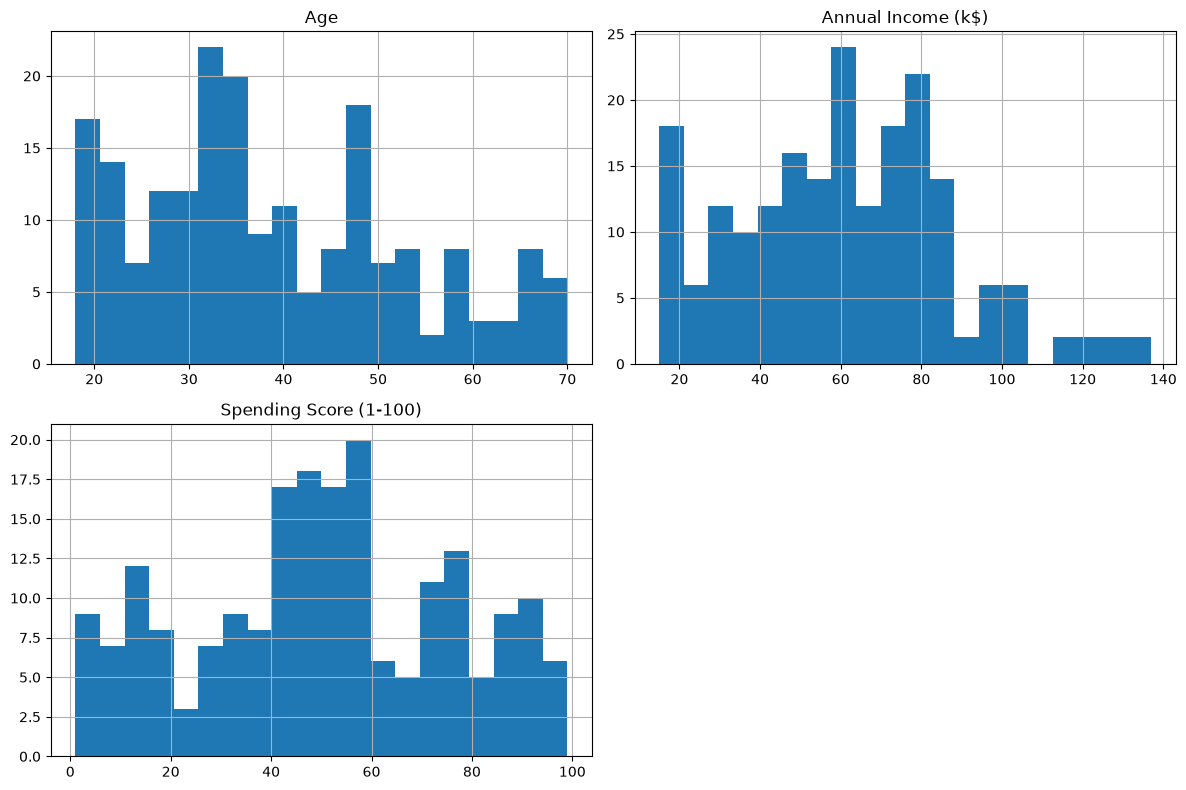

In [8]:
X.hist(
    figsize=(12, 8),
    bins=20
)

plt.tight_layout()
plt.show()

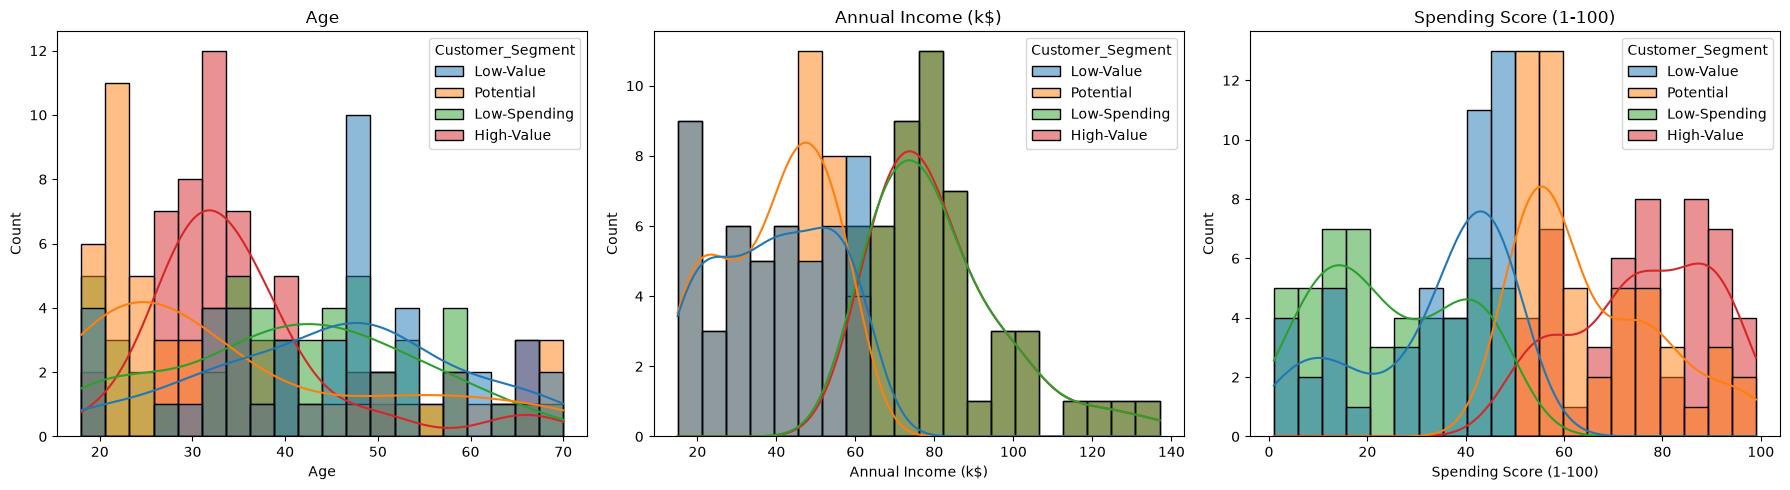

In [9]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for i, feature in enumerate(features):
    
    sns.histplot(
        data=df,
        x=feature,
        hue="Customer_Segment",
        bins=20,
        kde=True,
        ax=axes[i]
    )
    
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

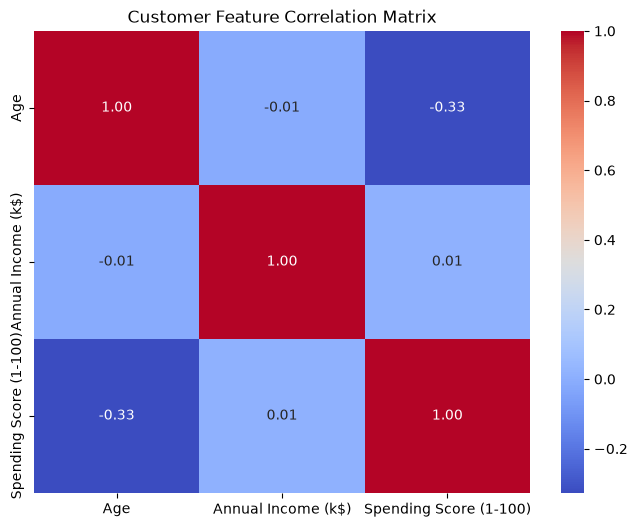

In [10]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Customer Feature Correlation Matrix")

plt.show()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (160, 3)
Testing data : (40, 3)


In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
def multivariate_gaussian(x, mean, covariance):
    
    x = np.asarray(x)
    mean = np.asarray(mean)
    
    d = len(mean)
    
    coefficient = 1 / (
        (2 * np.pi) ** (d / 2) *
        np.sqrt(np.linalg.det(covariance))
    )
    
    exponent = -0.5 * (
        (x - mean).T @
        np.linalg.inv(covariance) @
        (x - mean)
    )
    
    return coefficient * np.exp(exponent)

In [14]:
mean = np.array([0, 0])

covariance = np.array([
    [1, 0],
    [0, 1]
])

point = np.array([0, 0])

print(
    multivariate_gaussian(
        point,
        mean,
        covariance
    )
)

0.15915494309189535


In [15]:
x = np.linspace(-4, 4, 100)

y_grid = np.linspace(-4, 4, 100)

X_grid, Y_grid = np.meshgrid(
    x,
    y_grid
)

points = np.dstack(
    (X_grid, Y_grid)
)

In [16]:
mean = np.array([0, 0])

covariance = np.array([
    [1, 0],
    [0, 1]
])

Z = np.zeros(X_grid.shape)

for i in range(X_grid.shape[0]):
    
    for j in range(X_grid.shape[1]):
        
        Z[i, j] = multivariate_gaussian(
            points[i, j],
            mean,
            covariance
        )

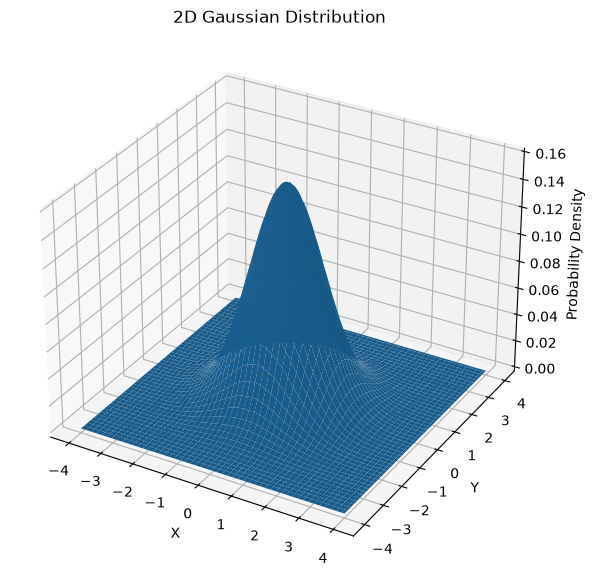

In [17]:
fig = plt.figure(figsize=(9, 7))

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.plot_surface(
    X_grid,
    Y_grid,
    Z
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Probability Density")

ax.set_title(
    "2D Gaussian Distribution"
)

plt.show()

In [18]:
mean = np.array([0, 0])

covariance = np.array([
    [2, 1.2],
    [1.2, 2]
])

Z = np.zeros(X_grid.shape)

for i in range(X_grid.shape[0]):
    
    for j in range(X_grid.shape[1]):
        
        Z[i, j] = multivariate_gaussian(
            points[i, j],
            mean,
            covariance
        )

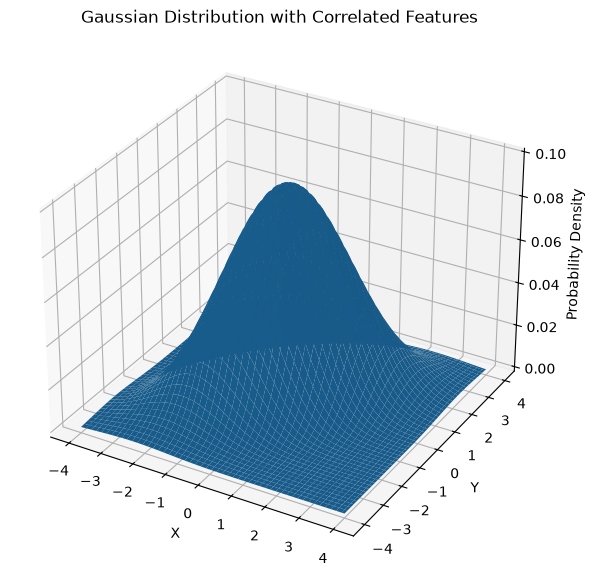

In [19]:
fig = plt.figure(figsize=(9, 7))

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.plot_surface(
    X_grid,
    Y_grid,
    Z
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Probability Density")

ax.set_title(
    "Gaussian Distribution with Correlated Features"
)

plt.show()

In [ ]:
classes = np.unique(y_train)

class_means = {}
class_covariances = {}
class_priors = {}

for cls in classes:
    class_data = X_train_scaled[y_train == cls]

    # Mean vector
    class_means[cls] = np.mean(class_data, axis=0)

    # Covariance matrix
    class_covariances[cls] = np.cov(
        class_data,
        rowvar=False
    )

    # Small regularization for numerical stability
    class_covariances[cls] += 1e-6 * np.eye(
        X_train_scaled.shape[1]
    )

    # Prior probability
    class_priors[cls] = len(class_data) / len(X_train_scaled)


print("Class Means:")
for cls in classes:
    print(cls, ":", class_means[cls])

print("\nClass Priors:")
for cls in classes:
    print(cls, ":", class_priors[cls])

Class Means:
0 : [-0.27269277  0.77221784  0.9909106 ]
1 : [ 0.19478055  0.84544944 -1.04266917]
2 : [ 0.37549165 -0.80947602 -0.61062639]
3 : [-0.26552842 -0.80825243  0.60176538]

Class Priors:
0 : 0.25
1 : 0.25
2 : 0.2375
3 : 0.2625


In [46]:
def gda_predict_proba(X):
    
    probabilities = []

    for x in X:

        class_scores = []

        for cls in classes:

            # P(X | Class)
            likelihood = multivariate_gaussian(
                x,
                class_means[cls],
                class_covariances[cls]
            )

            # P(X | Class) × P(Class)
            score = likelihood * class_priors[cls]

            class_scores.append(score)

        class_scores = np.array(class_scores)

        # Convert scores into posterior probabilities
        class_scores = class_scores / (
            np.sum(class_scores) + 1e-15
        )

        probabilities.append(class_scores)

    return np.array(probabilities)

In [47]:
y_prob_gda = gda_predict_proba(X_test_scaled)

y_pred_gda = classes[
    np.argmax(y_prob_gda, axis=1)
]

print("Predicted Classes:")
print(y_pred_gda)

Predicted Classes:
[0 2 0 3 3 3 3 2 3 2 0 2 1 3 2 0 0 1 3 0 1 1 1 3 1 1 0 0 3 3 0 3 0 3 3 2 3
 2 2 3]


In [48]:
print("GDA Probabilities for First Test Customer:")

for i, cls in enumerate(classes):
    
    label = label_encoder.inverse_transform([cls])[0]
    
    print(
        label,
        ":",
        round(y_prob_gda[0][i], 4)
    )

GDA Probabilities for First Test Customer:
High-Value : 0.9963
Low-Spending : 0.0001
Low-Value : 0.0037
Potential : 0.0


In [49]:
gda_accuracy = accuracy_score(
    y_test,
    y_pred_gda
)

print("GDA Accuracy:", gda_accuracy)
print("GDA Accuracy (%):", round(gda_accuracy * 100, 2))

GDA Accuracy: 0.875
GDA Accuracy (%): 87.5


In [50]:
print("GDA Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_gda,
        target_names=label_encoder.classes_
    )
)

GDA Classification Report:

              precision    recall  f1-score   support

  High-Value       1.00      1.00      1.00        10
Low-Spending       1.00      0.70      0.82        10
   Low-Value       1.00      0.80      0.89        10
   Potential       0.67      1.00      0.80        10

    accuracy                           0.88        40
   macro avg       0.92      0.88      0.88        40
weighted avg       0.92      0.88      0.88        40



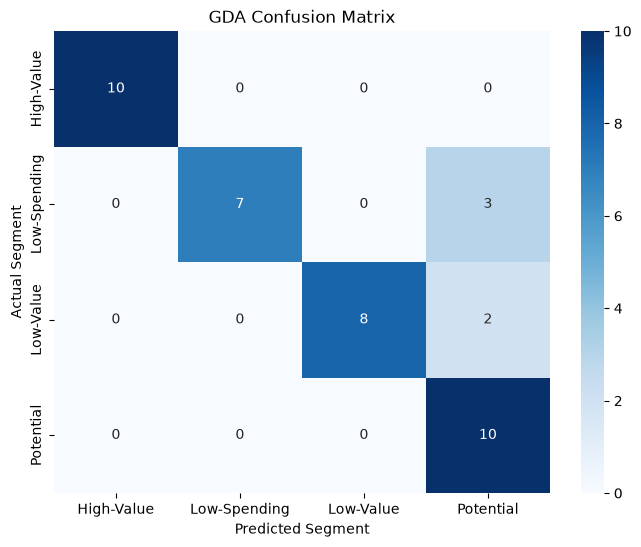

In [51]:
cm_gda = confusion_matrix(
    y_test,
    y_pred_gda
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_gda,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Segment")
plt.ylabel("Actual Segment")
plt.title("GDA Confusion Matrix")

plt.show()

In [52]:
lda_means = {}
lda_priors = {}

for cls in classes:
    
    class_data = X_train_scaled[y_train == cls]
    
    lda_means[cls] = np.mean(
        class_data,
        axis=0
    )
    
    lda_priors[cls] = len(class_data) / len(
        X_train_scaled
    )


# Calculate pooled covariance
pooled_covariance = np.zeros(
    (X_train_scaled.shape[1],
     X_train_scaled.shape[1])
)

for cls in classes:
    
    class_data = X_train_scaled[y_train == cls]
    
    covariance = np.cov(
        class_data,
        rowvar=False
    )
    
    pooled_covariance += (
        (len(class_data) - 1) * covariance
    )


pooled_covariance /= (
    len(X_train_scaled) - len(classes)
)

pooled_covariance += (
    1e-6 * np.eye(X_train_scaled.shape[1])
)

print("Pooled Covariance Matrix:")
print(pooled_covariance)

Pooled Covariance Matrix:
[[ 0.94352005  0.04876769 -0.08760512]
 [ 0.04876769  0.35396777 -0.00644888]
 [-0.08760512 -0.00644888  0.30679284]]


In [53]:
def lda_predict(X):

    predictions = []

    inv_covariance = np.linalg.inv(
        pooled_covariance
    )

    for x in X:

        class_scores = []

        for cls in classes:

            mean = lda_means[cls]
            prior = lda_priors[cls]

            score = (
                x.T @ inv_covariance @ mean
                - 0.5 * mean.T @ inv_covariance @ mean
                + np.log(prior)
            )

            class_scores.append(score)

        predicted_class = classes[
            np.argmax(class_scores)
        ]

        predictions.append(predicted_class)

    return np.array(predictions)

In [54]:
y_pred_lda = lda_predict(
    X_test_scaled
)

print("LDA Predictions:")
print(y_pred_lda)

LDA Predictions:
[0 2 0 2 3 3 3 2 2 2 0 2 1 3 2 0 0 1 3 0 1 1 1 3 1 1 0 0 1 3 0 3 0 1 2 2 2
 2 2 3]


In [55]:
lda_accuracy = accuracy_score(
    y_test,
    y_pred_lda
)

print(
    "LDA Accuracy:",
    round(lda_accuracy * 100, 2),
    "%"
)

print("\nLDA Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_lda,
        target_names=label_encoder.classes_
    )
)

LDA Accuracy: 95.0 %

LDA Classification Report:

              precision    recall  f1-score   support

  High-Value       1.00      1.00      1.00        10
Low-Spending       1.00      0.90      0.95        10
   Low-Value       0.83      1.00      0.91        10
   Potential       1.00      0.90      0.95        10

    accuracy                           0.95        40
   macro avg       0.96      0.95      0.95        40
weighted avg       0.96      0.95      0.95        40



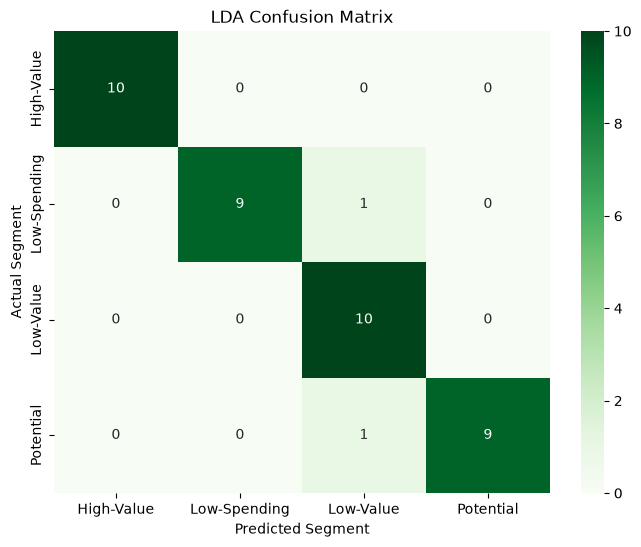

In [56]:
cm_lda = confusion_matrix(
    y_test,
    y_pred_lda
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_lda,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Segment")
plt.ylabel("Actual Segment")
plt.title("LDA Confusion Matrix")

plt.show()

In [57]:
logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

y_pred_logistic = logistic_model.predict(
    X_test_scaled
)

y_prob_logistic = logistic_model.predict_proba(
    X_test_scaled
)

print("Logistic Regression Predictions:")
print(y_pred_logistic)

Logistic Regression Predictions:
[0 2 0 1 3 3 3 2 2 2 0 2 1 3 2 0 0 1 3 0 1 1 1 3 1 1 0 0 0 3 0 3 0 1 2 2 3
 2 2 3]


In [58]:
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

print(
    "Logistic Regression Accuracy:",
    round(logistic_accuracy * 100, 2),
    "%"
)

print("\nLogistic Regression Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=label_encoder.classes_
    )
)

Logistic Regression Accuracy: 97.5 %

Logistic Regression Classification Report:

              precision    recall  f1-score   support

  High-Value       0.91      1.00      0.95        10
Low-Spending       1.00      0.90      0.95        10
   Low-Value       1.00      1.00      1.00        10
   Potential       1.00      1.00      1.00        10

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



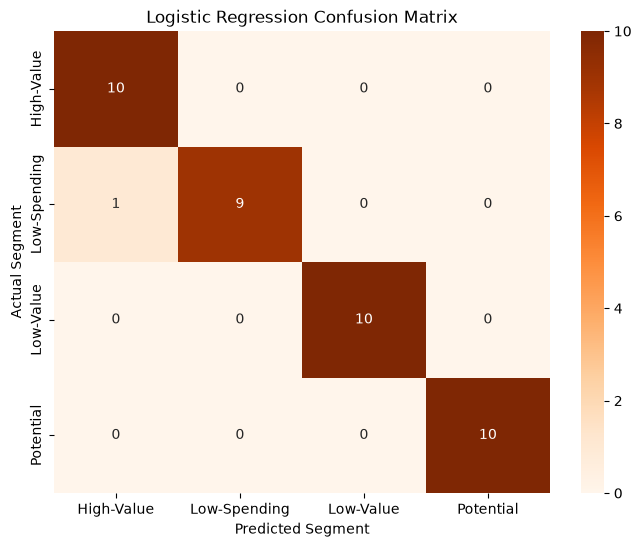

In [59]:
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Segment")
plt.ylabel("Actual Segment")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [60]:
comparison = pd.DataFrame({
    "Model": [
        "GDA",
        "LDA",
        "Logistic Regression"
    ],
    
    "Accuracy": [
        gda_accuracy,
        lda_accuracy,
        logistic_accuracy
    ]
})

comparison["Accuracy (%)"] = (
    comparison["Accuracy"] * 100
)

print(comparison)

                 Model  Accuracy  Accuracy (%)
0                  GDA     0.875          87.5
1                  LDA     0.950          95.0
2  Logistic Regression     0.975          97.5


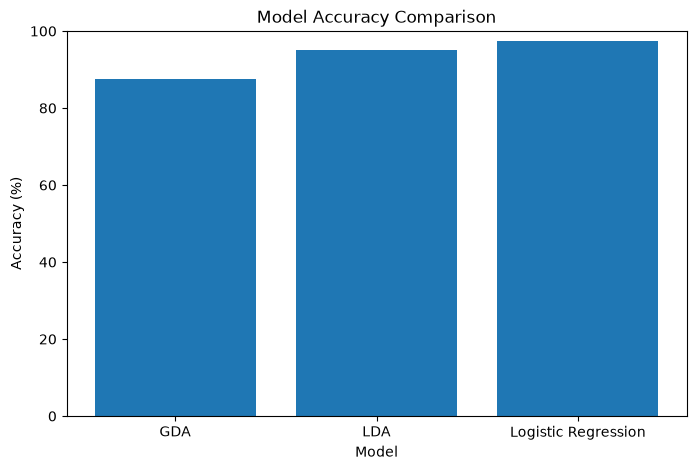

In [61]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy (%)"]
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Model Accuracy Comparison")

plt.ylim(0, 100)

plt.show()

In [62]:
segment_summary = df.groupby(
    "Customer_Segment"
).agg({
    "Age": "mean",
    "Annual Income (k$)": "mean",
    "Spending Score (1-100)": "mean"
}).round(2)

print(segment_summary)

                    Age  Annual Income (k$)  Spending Score (1-100)
Customer_Segment                                                   
High-Value        35.04               81.66                   76.18
Low-Spending      40.86               81.46                   24.76
Low-Value         45.10               39.56                   33.33
Potential         34.81               39.56                   65.25


Customer_Segment
Potential       52
Low-Spending    50
High-Value      50
Low-Value       48
Name: count, dtype: int64


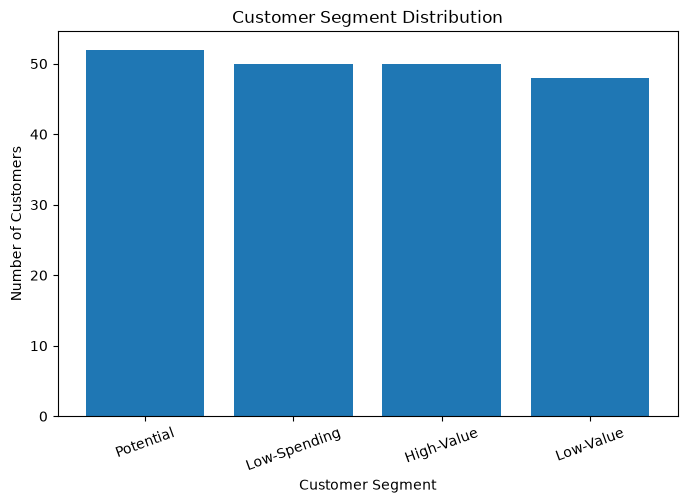

In [63]:
segment_counts = df[
    "Customer_Segment"
].value_counts()

print(segment_counts)

plt.figure(figsize=(8, 5))

plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Customer Segment Distribution")

plt.xticks(rotation=20)

plt.show()

In [64]:
print("FINAL MODEL RESULTS")
print("=" * 40)

print(
    "GDA Accuracy:",
    round(gda_accuracy * 100, 2),
    "%"
)

print(
    "LDA Accuracy:",
    round(lda_accuracy * 100, 2),
    "%"
)

print(
    "Logistic Regression Accuracy:",
    round(logistic_accuracy * 100, 2),
    "%"
)

FINAL MODEL RESULTS
GDA Accuracy: 87.5 %
LDA Accuracy: 95.0 %
Logistic Regression Accuracy: 97.5 %


In [65]:
best_model = comparison.loc[
    comparison["Accuracy"].idxmax()
]

print("Best Model:", best_model["Model"])
print(
    "Best Accuracy:",
    round(best_model["Accuracy (%)"], 2),
    "%"
)

Best Model: Logistic Regression
Best Accuracy: 97.5 %


In [66]:
print("CUSTOMER SEGMENT INSIGHTS")
print("=" * 40)

for segment in segment_summary.index:
    
    print("\n", segment)
    
    print(
        "Average Age:",
        segment_summary.loc[segment, "Age"]
    )
    
    print(
        "Average Income:",
        segment_summary.loc[
            segment,
            "Annual Income (k$)"
        ]
    )
    
    print(
        "Average Spending Score:",
        segment_summary.loc[
            segment,
            "Spending Score (1-100)"
        ]
    )

CUSTOMER SEGMENT INSIGHTS

 High-Value
Average Age: 35.04
Average Income: 81.66
Average Spending Score: 76.18

 Low-Spending
Average Age: 40.86
Average Income: 81.46
Average Spending Score: 24.76

 Low-Value
Average Age: 45.1
Average Income: 39.56
Average Spending Score: 33.33

 Potential
Average Age: 34.81
Average Income: 39.56
Average Spending Score: 65.25
